In [173]:
import pandas as pd
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import random
import shutil
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report, roc_curve
from sklearn.inspection import permutation_importance
from lime import lime_image
from skimage.segmentation import mark_boundaries
from skimage.color import gray2rgb

In [2]:
# Load JSON
photos_df = pd.read_json("data/photos.json", lines=True)

In [3]:
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


Dataset with 200k non null entries.

In [5]:
photos_df['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

We have 5 distinct labels, related to restaurants, lets see a few photos inside the folder.

In [7]:
selected_photos = ['Km1nuFtDgB-Ln1P4L3U-bg.jpg',
 'cVdE5e9k4bP2kBUlVvMB0A.jpg',
 'j7Qi42Z2UpVr2aR3te-blQ.jpg',
 'bqXKw83_aLw7FJ9F9-lQ2w.jpg',
 'Xd0f5yYNIiDYC2pXgyg63w.jpg',
 'bJbp_NJKIinHB_uh7892oQ.jpg',
 'zxmdEhJqWc-eHQgsXDamPQ.jpg',
 'uaI4Ww9YvniXhanm34tqPA.jpg',
 'Pw-q9AkO4hq3j6P1tcuD2g.jpg']

In [8]:
destination_folder = 'data/random_photos'

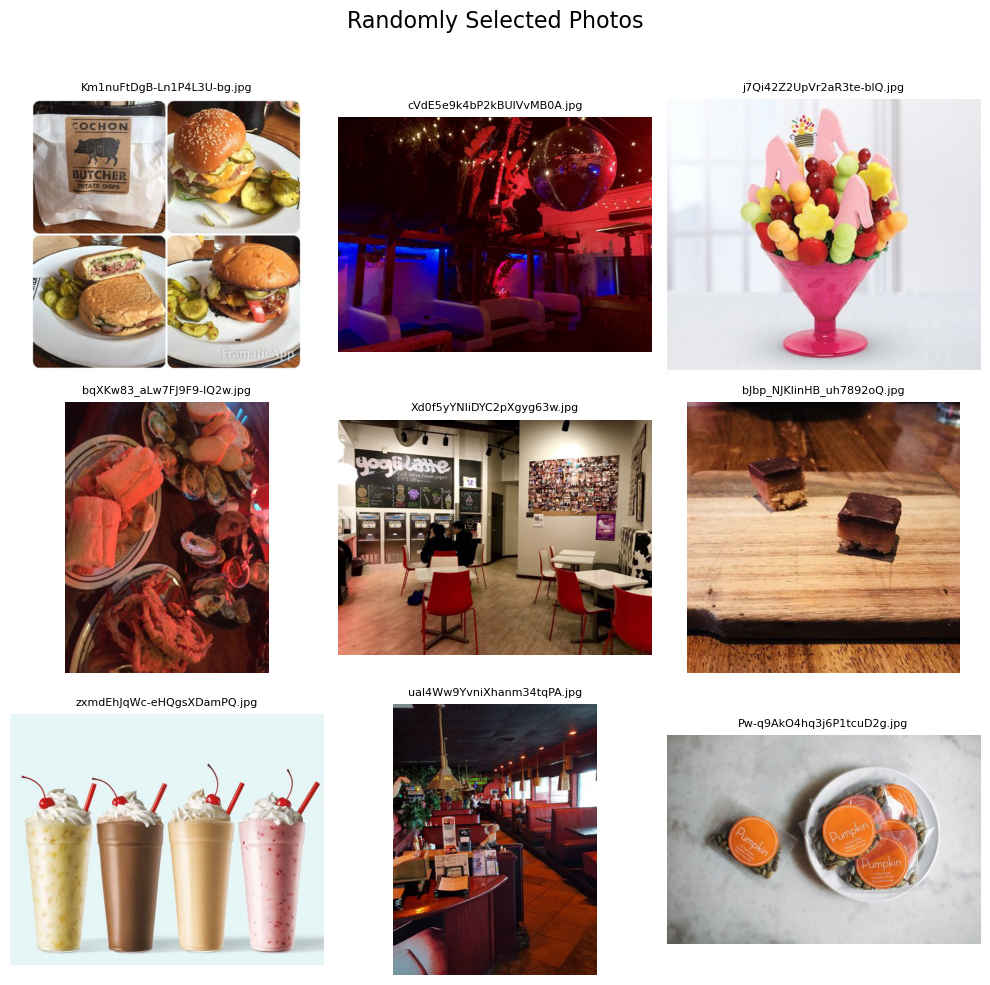

In [15]:
# Display the selected photos in a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle("Randomly Selected Photos", fontsize=16)

for i, photo in enumerate(selected_photos):
    img_path = os.path.join(destination_folder, photo)
    img = Image.open(img_path)

    row, col = divmod(i, 3)
    axes[row, col].imshow(img)
    axes[row, col].axis('off')
    axes[row, col].set_title(photo, fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

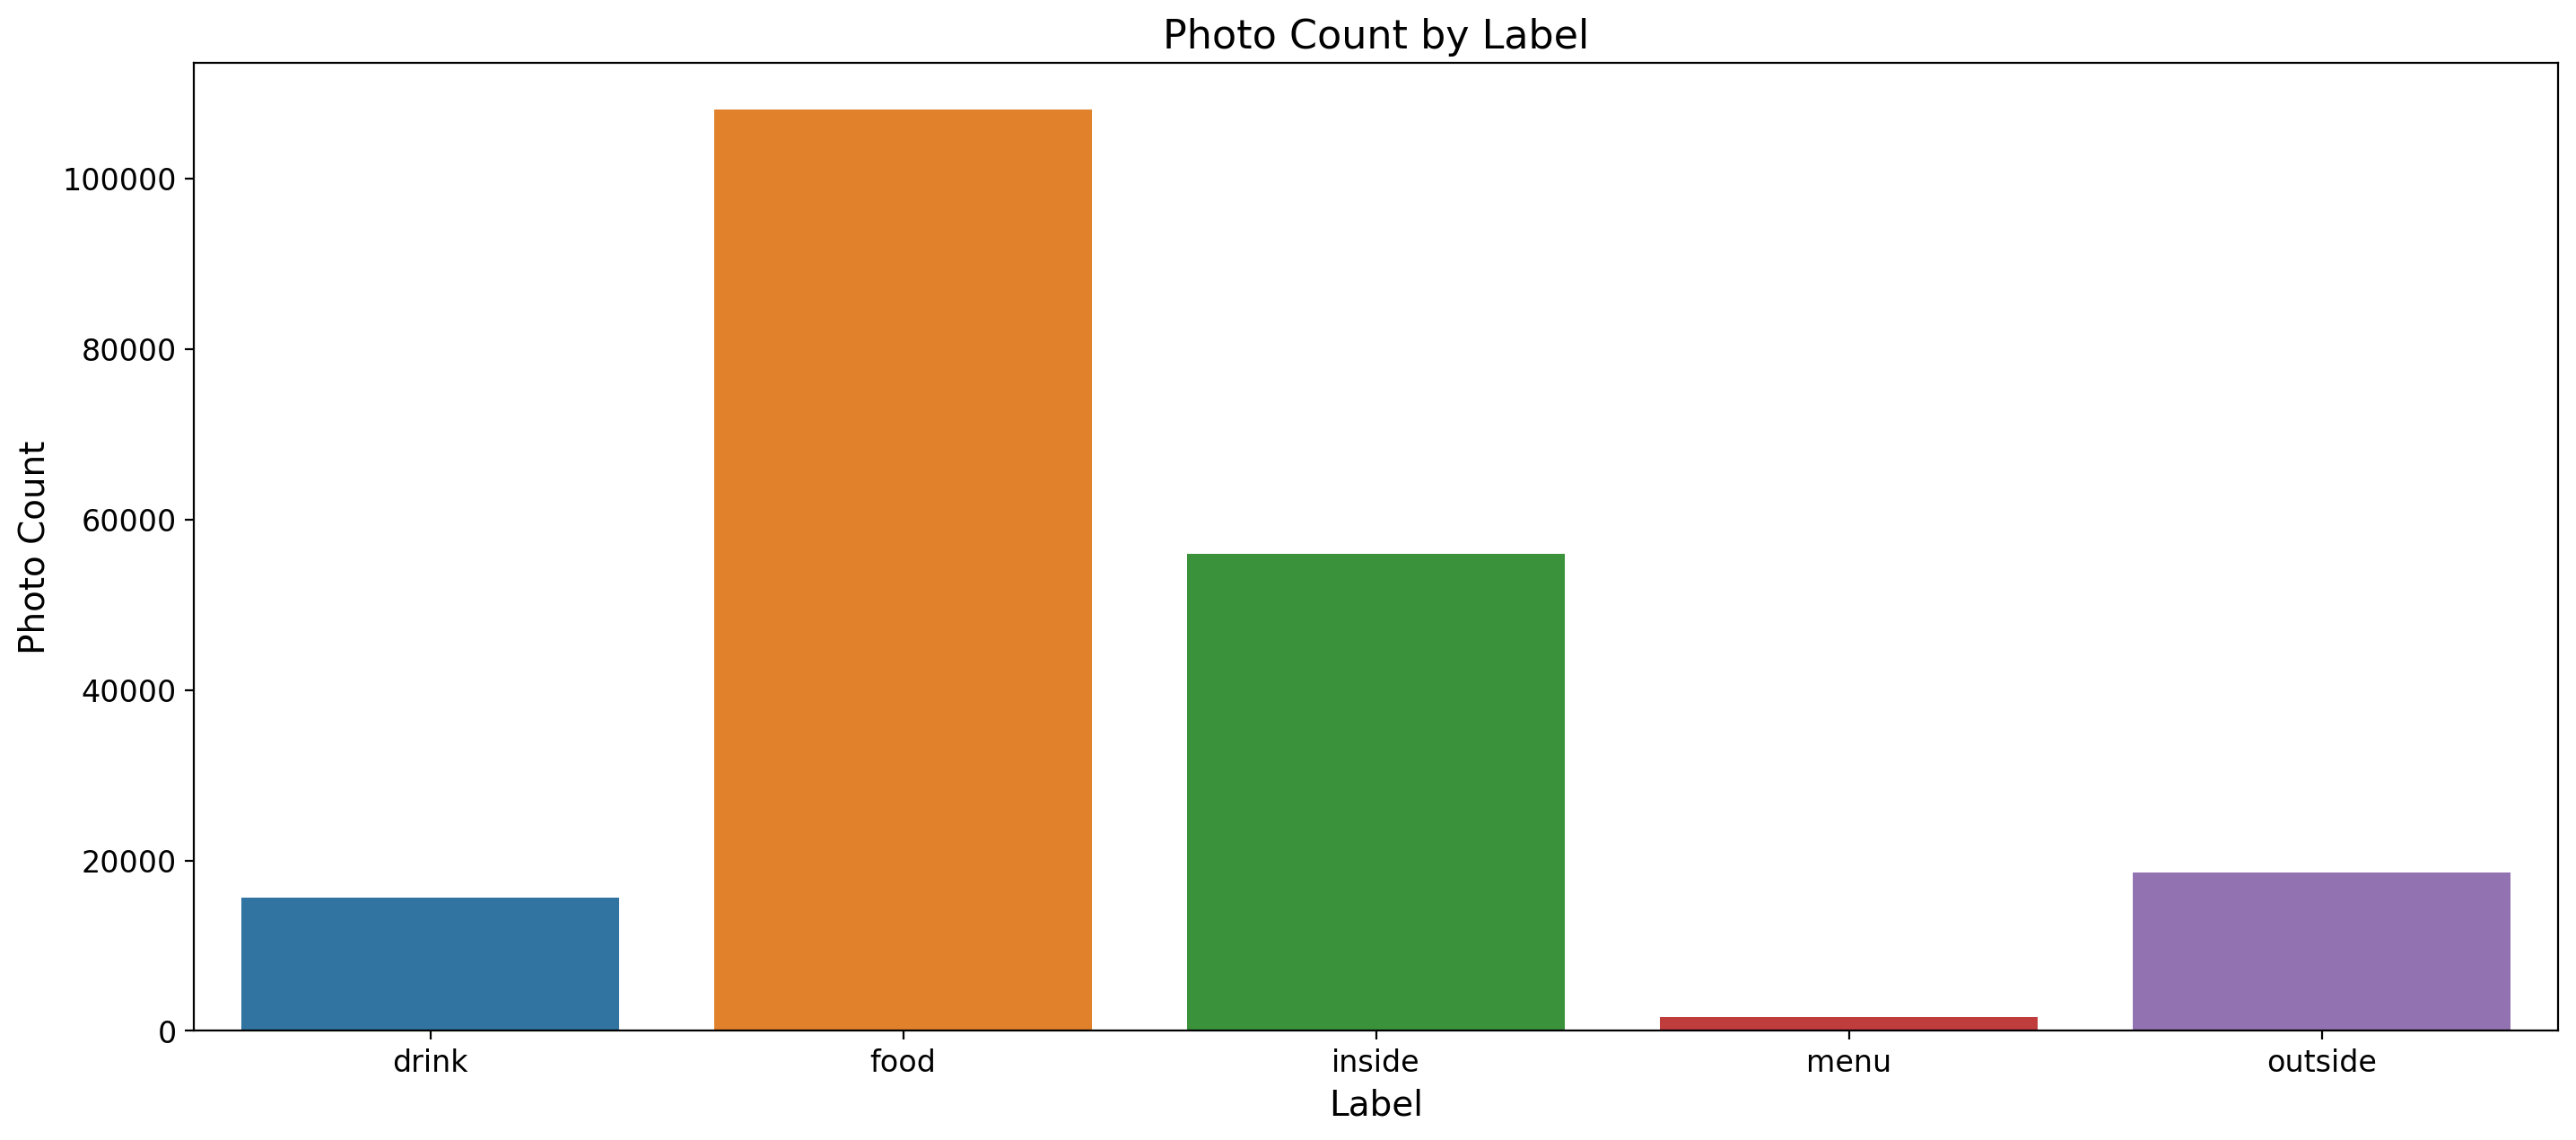

In [17]:
# Plot
plt.figure(figsize=[17, 7],dpi=200)
sns.barplot(data=photos_df.groupby('label')['photo_id'].count().to_frame().reset_index(),x='label', hue='label', y='photo_id')
plt.title("Photo Count by Label", fontsize=16)
plt.xlabel("Label", fontsize=14)
plt.ylabel("Photo Count", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

There's heavy imbalance to what's a drink, what's a menu, what's outside. Maybe we can use augmentation later to enhance the models.
<b> Let's start preprocessing the model.

## Let's first balance the model and remove some images so that we can run it faster, we will let the 200k for when we start dealing with DNN/CNN

In [23]:
# Here we run the balanced subset.py this will make running knn and svm easier

Balanced subset with 13678 images saved to data/balanced_subset.json.
Copied 13678 images to data/balanced_photos..

In [114]:
balanced_df = pd.read_json("data/balanced_subset.json")

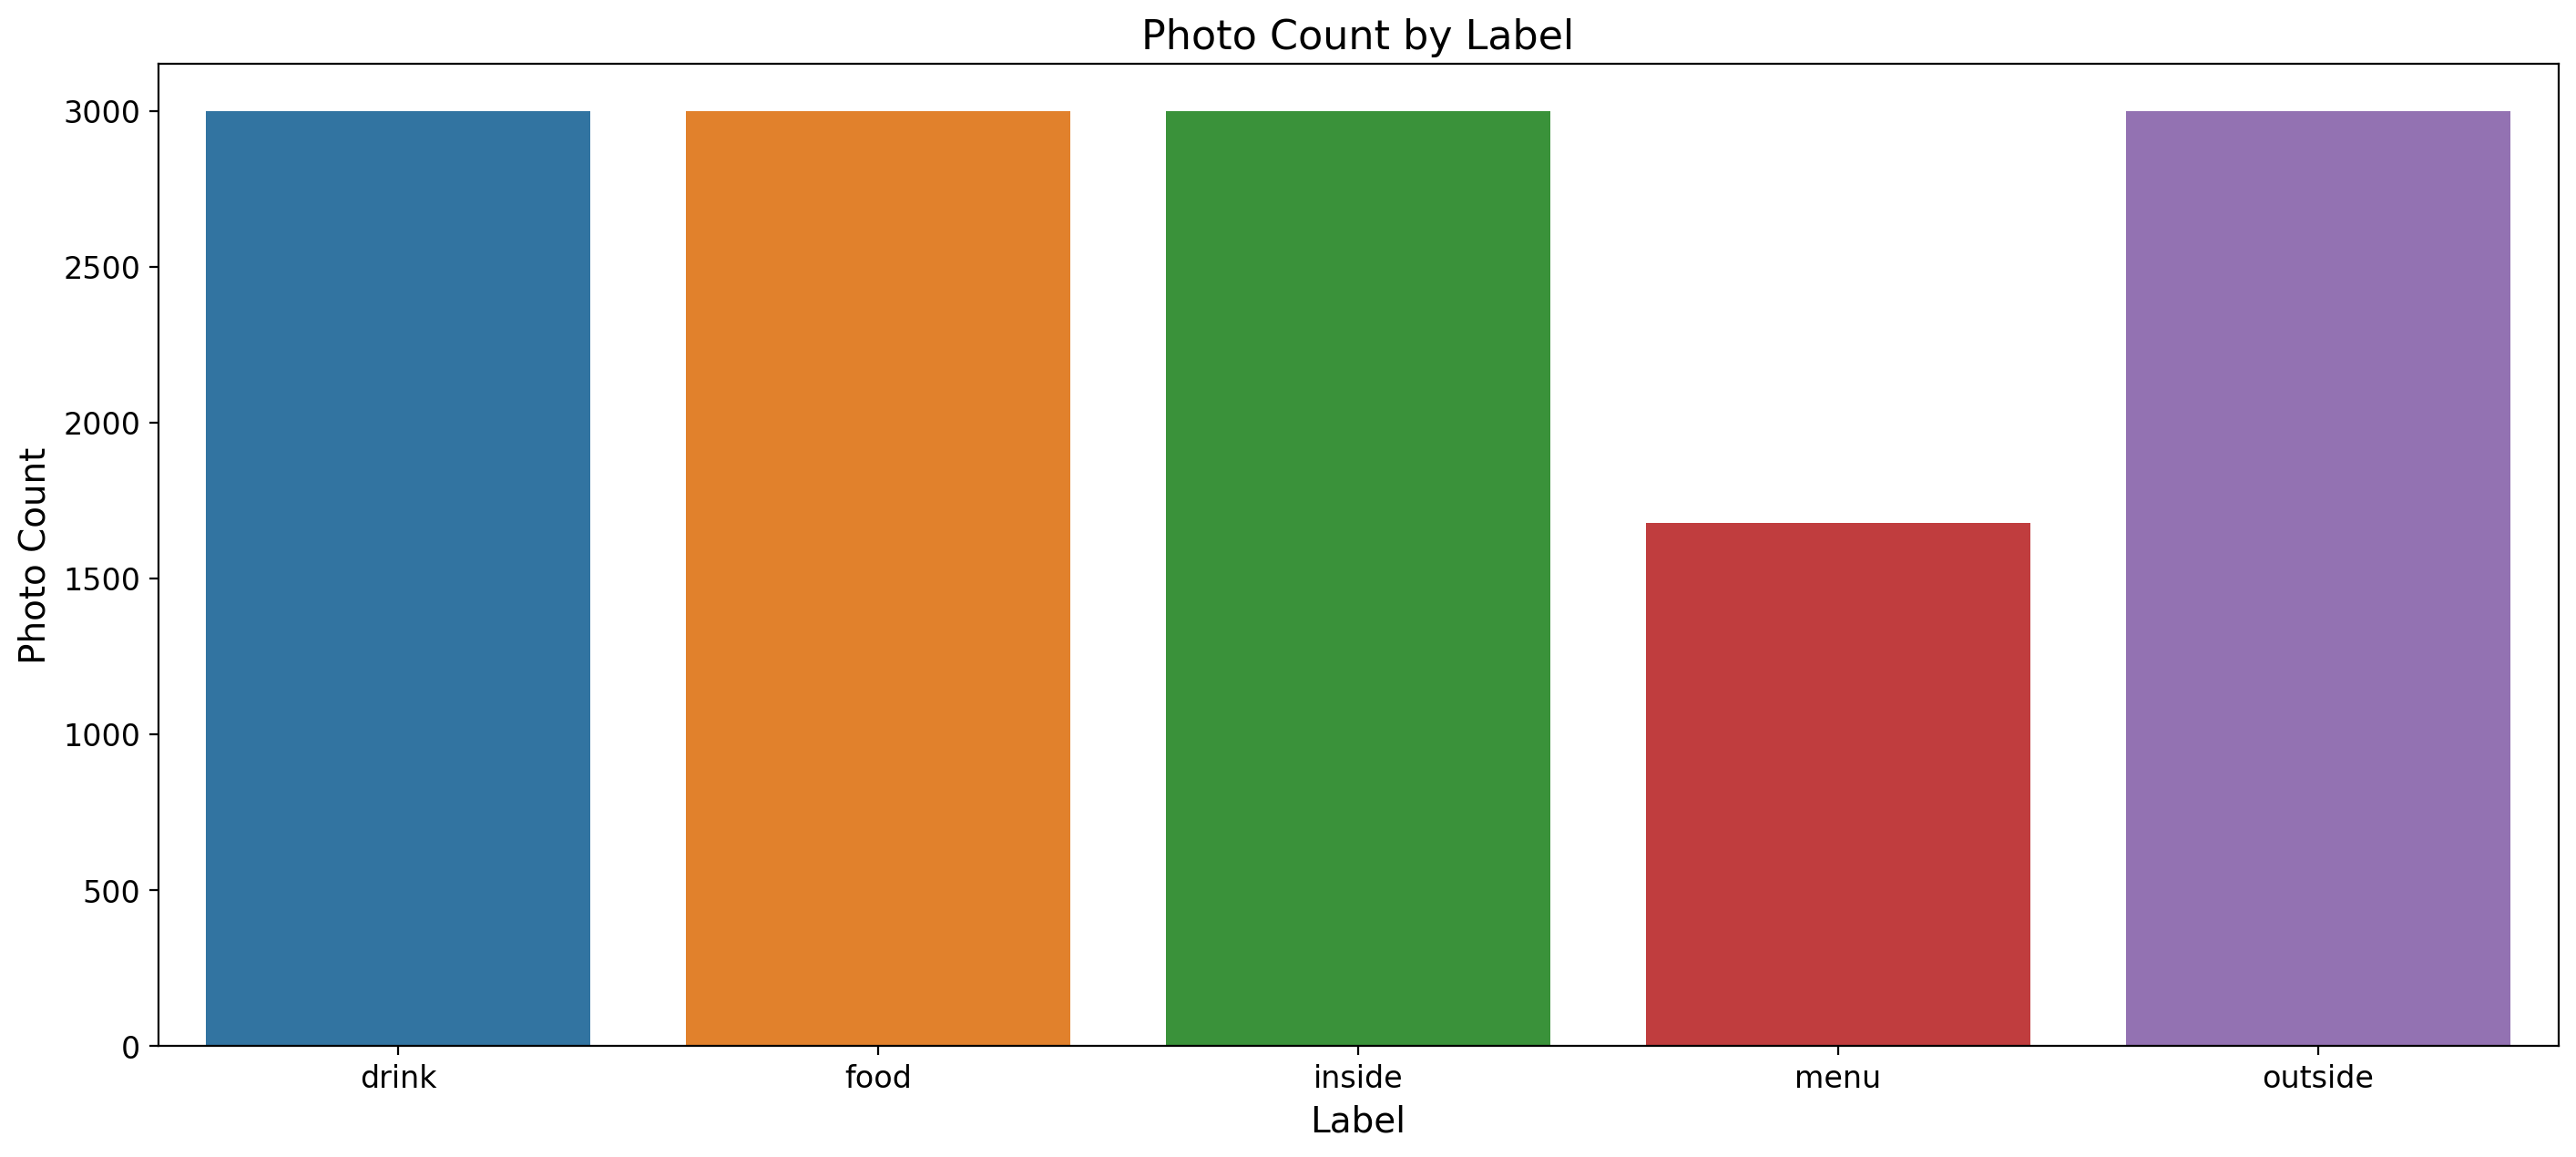

In [116]:
# Plot
plt.figure(figsize=[17, 7],dpi=200)
sns.barplot(data=balanced_df.groupby('label')['photo_id'].count().to_frame().reset_index(),x='label', hue='label', y='photo_id')
plt.title("Photo Count by Label", fontsize=16)
plt.xlabel("Label", fontsize=14)
plt.ylabel("Photo Count", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

It's already more balanced. With exception of menu that there are too few images.

### Let's load and preprocess the images

In [127]:
def load_and_preprocess_images(photo_ids, img_dir):
    images = []
    missing_ids = []
    for photo_id in photo_ids:
        img_path = os.path.join(img_dir, f"{photo_id}.jpg")
        try:
            img = Image.open(img_path).resize(IMAGE_SIZE)
            images.append(np.array(img))
        except Exception as e:
            missing_ids.append(photo_id)
            print(f"Error loading image {photo_id}: {e}")
    print(f"Missing or problematic images: {len(missing_ids)}")
    return np.array(images), missing_ids

# Load the dataset
X, missing_ids = load_and_preprocess_images(balanced_df["photo_id"], "data/balanced_photos")
y = balanced_df[~balanced_df["photo_id"].isin(missing_ids)]["label"]

Error loading image 2S78q98b_VpBD7vkrDE5-A: cannot identify image file 'C:\\Users\\leand\\GitHub\\AISC-T3-Grp2\\AISC2008 - Computer Vision\\Case Study 1\\Leandro\\data\\balanced_photos\\2S78q98b_VpBD7vkrDE5-A.jpg'
Error loading image rLafN9k3_AF5lZU0cs3LZg: cannot identify image file 'C:\\Users\\leand\\GitHub\\AISC-T3-Grp2\\AISC2008 - Computer Vision\\Case Study 1\\Leandro\\data\\balanced_photos\\rLafN9k3_AF5lZU0cs3LZg.jpg'
Missing or problematic images: 2


In [129]:
X.shape

(13676, 64, 64, 3)

In [130]:
y.shape

(13676,)

In [131]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

### Split into train test and val

In [133]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### Let's start with the KNN method now.

First let's flatten it to run.

In [136]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [137]:
# Initialize the kNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_flat, y_train)

KNeighborsClassifier()

In [ ]:
# Predict on test data
y_test_pred = knn.predict(X_test_flat)
y_test_probs = knn.predict_proba(X_test_flat)

In [138]:
# Same for val
y_val_pred = knn.predict(X_val_flat)
y_val_probs = knn.predict_proba(X_val_flat)

In [ ]:
# Evaluate
cm = confusion_matrix(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_probs, multi_class="ovr")
print("Confusion Matrix:\n", cm)
print("AUC Score:", auc)
print("Classification Report:\n", classification_report(y_test, y_test_pred))

In [139]:
# Evaluate
cm = confusion_matrix(y_val, y_val_pred)
auc = roc_auc_score(y_val, y_val_probs, multi_class="ovr")
print("Confusion Matrix:\n", cm)
print("AUC Score:", auc)
print("Classification Report:\n", classification_report(y_val, y_val_pred))

Confusion Matrix:
 [[173  49  48 137  52]
 [ 84 129  34 152  21]
 [ 36  21 112 206  69]
 [ 42  15  25 170  12]
 [ 30  24  33 114 263]]
AUC Score: 0.7286778963454362
Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.38      0.42       459
           1       0.54      0.31      0.39       420
           2       0.44      0.25      0.32       444
           3       0.22      0.64      0.33       264
           4       0.63      0.57      0.60       464

    accuracy                           0.41      2051
   macro avg       0.46      0.43      0.41      2051
weighted avg       0.48      0.41      0.42      2051



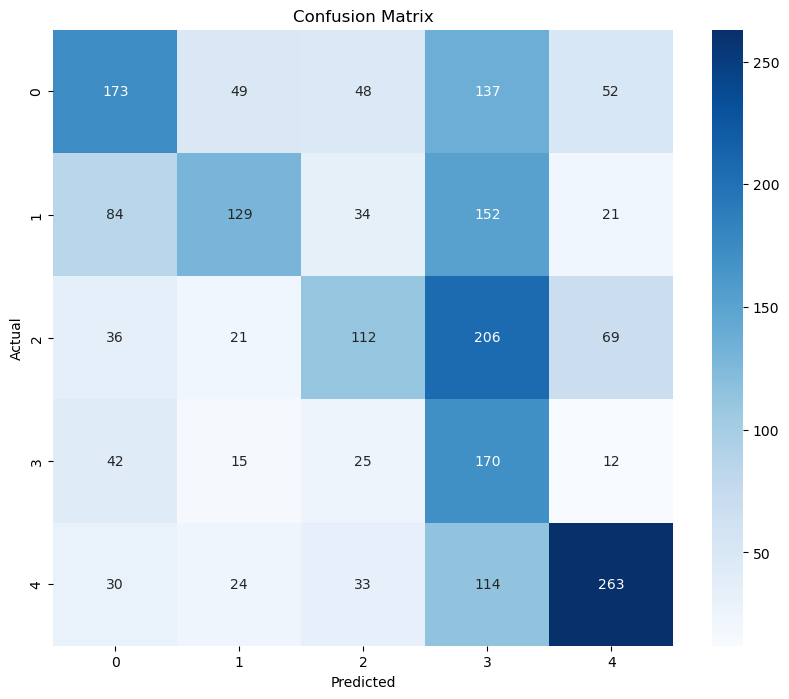

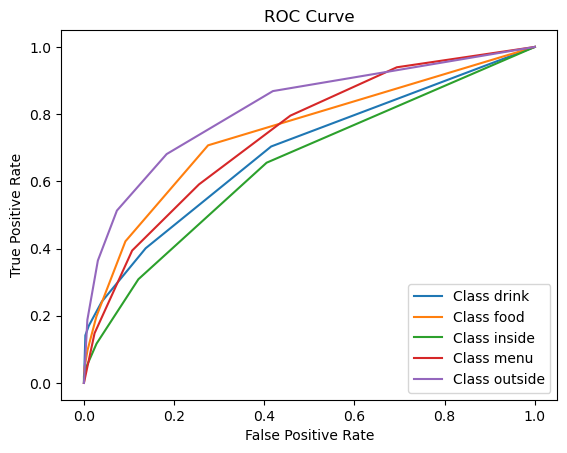

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Plot ROC Curve (One-vs-Rest)
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_val == i, y_val_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {label_encoder.classes_[i]}")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

<b> The model looks very poor. In some parts way worse than a coin. Since we are balanced the data let's see if we can get something from global and local interpretability and check if we can improve it somehow. It could be due to the low amount of images but for the sake of the exercise it's fine.

### Global Interpretation

Nearest Neighbors' Labels: [3 4 3 1 0]


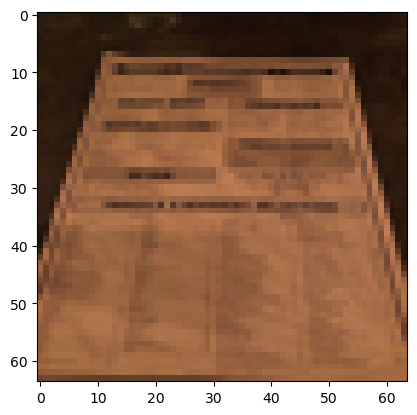

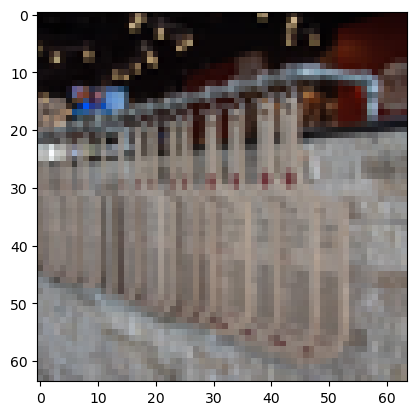

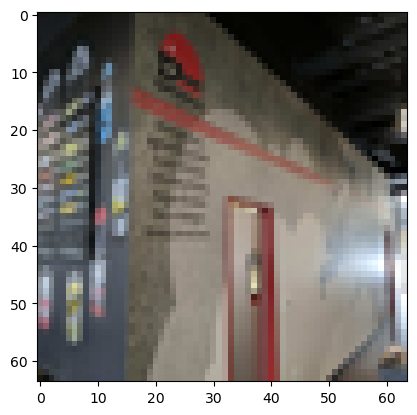

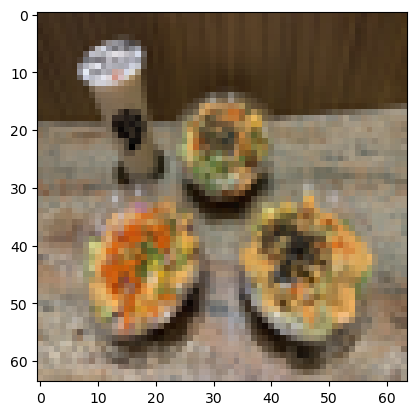

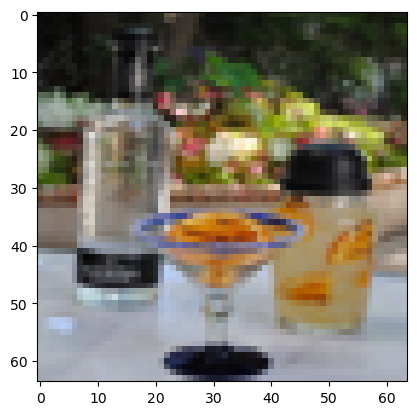

In [161]:
def visualize_nearest_neighbors(knn, instance, X_train, y_train):
    distances, indices = knn.kneighbors(instance.reshape(1, -1))
    print("Nearest Neighbors' Labels:", y_train[indices.flatten()])

    for idx in indices.flatten():
        plt.imshow(X_train[idx].reshape(64, 64, 3).astype("uint8"))
        plt.show()

visualize_nearest_neighbors(knn, X_test_flat[0], X_train, y_train)

In [ ]:
def preprocess_image(image):
    """Flatten the image to match the input expected by kNN."""
    return image.reshape(1, -1)

def predict_proba_for_lime(images):
    """Flatten all images for kNN and return predicted probabilities."""
    flattened_images = np.array([img.flatten() for img in images])
    return knn.predict_proba(flattened_images)

  0%|          | 0/1000 [00:00<?, ?it/s]

Top labels explained: [3, 4, 1, 0, 2]


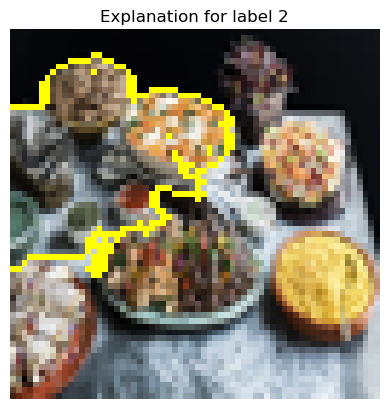

Predicted probabilities: [[0.2 0.2 0.  0.4 0.2]]
True label probability: 0.0


In [177]:
# Example LIME explanation
explainer = lime_image.LimeImageExplainer()

# Explain the first test image
explanation = explainer.explain_instance(
    X_test[0],  # The test image
    predict_proba_for_lime,  # Wrapped prediction function
    labels=[y_test[0]],  # Force LIME to explain the true label
    hide_color=0,
    num_samples=1000
)

# Check the top labels explained
print("Top labels explained:", explanation.top_labels)

# Visualize the explanation for the true label
temp, mask = explanation.get_image_and_mask(
    label=y_test[0],  # The true label
    positive_only=True,  # Show only positive contributions
    num_features=10,  # Number of features to display
    hide_rest=False  # Show the rest of the image
)

# Convert `temp` to ensure it is in the correct format for visualization
if len(temp.shape) == 2:  # If grayscale, convert to RGB
    temp = gray2rgb(temp)

# Overlay the mask on the image
overlay = mark_boundaries(temp, mask)

# Plot the image with the explanation
plt.imshow(overlay)
plt.title(f"Explanation for label {y_test[0]}")
plt.axis("off")
plt.show()

# Debugging: Check predicted probabilities
proba = knn.predict_proba(preprocess_image(X_test[0]))
print(f"Predicted probabilities: {proba}")
print(f"True label probability: {proba[0, y_test[0]]}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Top labels explained: [4, 3, 2, 1, 0]


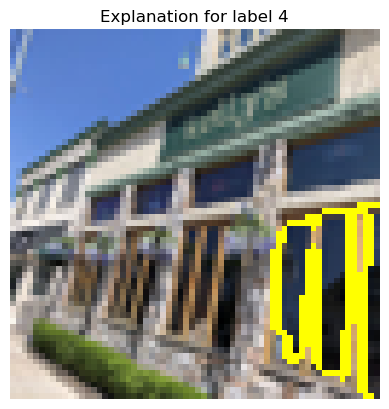

Predicted probabilities: [[0.  0.  0.  0.2 0.8]]
True label probability: 0.8


In [181]:
# Example LIME explanation
explainer = lime_image.LimeImageExplainer()

# Explain the first test image
explanation = explainer.explain_instance(
    X_test[1],  # The test image
    predict_proba_for_lime,  # Wrapped prediction function
    labels=[y_test[1]],  # Force LIME to explain the true label
    hide_color=0,
    num_samples=1000
)

# Check the top labels explained
print("Top labels explained:", explanation.top_labels)

# Visualize the explanation for the true label
temp, mask = explanation.get_image_and_mask(
    label=y_test[1],  # The true label
    positive_only=True,  # Show only positive contributions
    num_features=10,  # Number of features to display
    hide_rest=False  # Show the rest of the image
)

# Convert `temp` to ensure it is in the correct format for visualization
if len(temp.shape) == 2:  # If grayscale, convert to RGB
    temp = gray2rgb(temp)

# Overlay the mask on the image
overlay = mark_boundaries(temp, mask)

# Plot the image with the explanation
plt.imshow(overlay)
plt.title(f"Explanation for label {y_test[1]}")
plt.axis("off")
plt.show()

# Debugging: Check predicted probabilities
proba = knn.predict_proba(preprocess_image(X_test[1]))
print(f"Predicted probabilities: {proba}")
print(f"True label probability: {proba[0, y_test[1]]}")